In [ ]:
# ─── Imports ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
# For ordinal regression (approximation)
import mord

sns.set(style="whitegrid")
%matplotlib inline

print("Libraries loaded.")

Libraries loaded.


Experiment 5.1 – Poisson Regression (GLM)

In [ ]:
# ─── 5.1 Poisson Regression ──────────────────────────────────────

# Load Student Performance (Portuguese version is larger)
student_performance = fetch_ucirepo(id=320)

# We use the Portuguese subject dataset (larger)
X = student_performance.data.features
y_raw = student_performance.data.targets  # G3 final grade

df_student = X.copy()
df_student['G3'] = y_raw['G3']

print("Student Performance shape:", df_student.shape)
df_student.head(3)

# ─── Create synthetic count target: Number of Late Submissions ───
np.random.seed(42)

Student Performance shape: (649, 31)


In [ ]:
# Make it plausible: students with low study time & low attendance → more lates
df_student['study_hours_per_week'] = df_student['studytime'] * 4 + np.random.normal(0, 2, len(df_student)).clip(0)
df_student['attendance_pct']       = 95 - (df_student['absences'] * 1.8).clip(0, 60) + np.random.normal(0, 5, len(df_student))

# Synthetic late submissions (strong negative relation with study & attendance)
lambda_base = np.exp(1.2 - 0.18 * df_student['study_hours_per_week'] - 0.04 * df_student['attendance_pct'])
df_student['late_submissions'] = np.random.poisson(lambda_base).astype(int)

print("Created synthetic target 'late_submissions'")
print(df_student['late_submissions'].value_counts().sort_index())

# Quick check mean ≈ variance ?
print("\nMean   :", df_student['late_submissions'].mean())
print("Variance:", df_student['late_submissions'].var())

Created synthetic target 'late_submissions'
late_submissions
0    631
1     18
Name: count, dtype: int64

Mean   : 0.02773497688751926
Variance: 0.02700736175312444


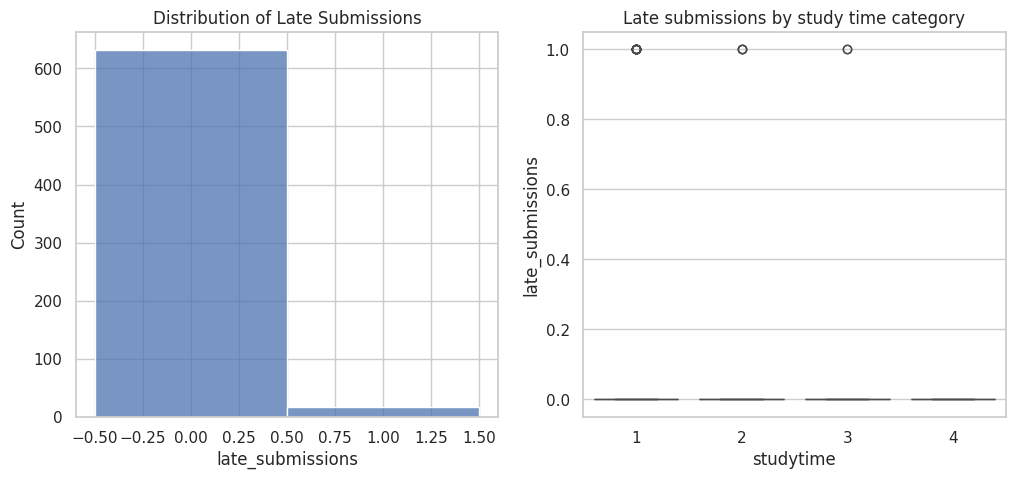

In [ ]:
# ─── EDA ─────────────────────────────────────────────────────────
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_student['late_submissions'], discrete=True)
plt.title("Distribution of Late Submissions")

plt.subplot(1,2,2)
sns.boxplot(x='studytime', y='late_submissions', data=df_student)
plt.title("Late submissions by study time category")
plt.show()

In [ ]:
# ─── Model 1: Only intercept ─────────────────────────────────────
# Fix: Ensure X_poisson has the same number of rows as y for the intercept
X_poisson = sm.add_constant(pd.DataFrame(index=y.index)) # Create a DataFrame with the correct index and let add_constant fill it
y = df_student['late_submissions']

model_null = sm.GLM(y, X_poisson, family=sm.families.Poisson()).fit()
print("Null model (intercept only)")
print(model_null.summary().tables[1])

Null model (intercept only)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.5851      0.236    -15.210      0.000      -4.047      -3.123


In [ ]:
# ─── Model 2: With predictors ────────────────────────────────────
predictors = ['study_hours_per_week', 'attendance_pct']
X = df_student[predictors].copy()
X = sm.add_constant(X)

model_full = sm.GLM(y, X, family=sm.families.Poisson()).fit()
print("\nFull Poisson model")
print(model_full.summary())

# Interpretation example
print("\nExponentiated coefficients (multiplicative effect on expected count):")
print(np.exp(model_full.params))


Full Poisson model
                 Generalized Linear Model Regression Results                  
Dep. Variable:       late_submissions   No. Observations:                  649
Model:                            GLM   Df Residuals:                      646
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -76.441
Date:                Thu, 12 Mar 2026   Deviance:                       116.88
Time:                        05:58:03   Pearson chi2:                     683.
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01859
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

In [ ]:
# ─── Compare models ──────────────────────────────────────────────
print(f"\nAIC  null = {model_null.aic:.1f}   full = {model_full.aic:.1f}")
print(f"BIC  null = {model_null.bic:.1f}   full = {model_full.bic:.1f}")

# ─── Predictions vs actual ───────────────────────────────────────
pred = model_full.predict(X)
print("\nSample of predicted vs actual counts:")
pd.DataFrame({'actual':y, 'predicted':pred.round(2)}).sample(10)

# RMSE (not ideal for counts, but for illustration)
print("RMSE:", np.sqrt(mean_squared_error(y, pred)))

# ─── When Poisson may fail ───────────────────────────────────────
print("\nNote: If variance >> mean (overdispersion) → consider NegativeBinomial")
print("   Variance / Mean ratio =", df_student['late_submissions'].var() / df_student['late_submissions'].mean())


AIC  null = 167.1   full = 158.9
BIC  null = -4067.0   full = -4066.2

Sample of predicted vs actual counts:
RMSE: 0.1618551853528095

Note: If variance >> mean (overdispersion) → consider NegativeBinomial
   Variance / Mean ratio = 0.9737654320987644


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


Experiment 5.2 – Multinomial & Ordinal Logistic Regression

In [ ]:
# ─── 5.2 Multinomial + Ordinal Logistic ──────────────────────────

# Load Bank Marketing dataset
bank_marketing = fetch_ucirepo(id=222)

df_bank = bank_marketing.data.features.copy()
df_bank['y'] = bank_marketing.data.targets['y']   # yes / no subscription

print("Bank Marketing shape:", df_bank.shape)
df_bank.head(3)

# ─── Create synthetic multinomial & ordinal targets ──────────────
np.random.seed(43)

Bank Marketing shape: (45211, 17)


In [ ]:
# Multinomial: Contact Outcome Type → Success / Failure / Unknown
df_bank['contact_outcome'] = np.random.choice(
    ['Success', 'Failure', 'Unknown'],
    size=len(df_bank),
    p=[0.11, 0.65, 0.24]   # roughly realistic
)

# Make it somewhat dependent on predictors
p_success = 1 / (1 + np.exp(-(-3.5 + 0.08*df_bank['age'] + 0.000015*df_bank['balance'] + 0.02*df_bank['duration'])))
df_bank['contact_outcome'] = np.where(
    np.random.rand(len(df_bank)) < p_success, 'Success',
    np.where(np.random.rand(len(df_bank)) < 0.75, 'Failure', 'Unknown')
)

In [ ]:
# Ordinal: Interest Level Low < Medium < High
interest_score = (
    0.06 * df_bank['age'] +
    0.000012 * df_bank['balance'] +
    0.035 * df_bank['duration'] +
    0.18 * df_bank['previous'] -
    1.8
)
df_bank['interest_level'] = pd.cut(
    interest_score,
    bins=[-np.inf, 2, 4, np.inf],
    labels=['Low', 'Medium', 'High']
).astype('category')

In [ ]:
print("\nMultinomial target distribution:")
print(df_bank['contact_outcome'].value_counts())

print("\nOrdinal target distribution:")
print(df_bank['interest_level'].value_counts())


Multinomial target distribution:
contact_outcome
Success    40595
Failure     3500
Unknown     1116
Name: count, dtype: int64

Ordinal target distribution:
interest_level
High      35633
Medium     7101
Low        2477
Name: count, dtype: int64


In [ ]:
# ... your previous preparation code ...

X_multi = sm.add_constant(df_model)

# ─── CRITICAL FIX ────────────────────────────────────────
# Convert all bool dummy columns to numeric (avoids object dtype in numpy)
X_multi = X_multi.astype(float)   # ← this single line usually solves it

# If you want to be more explicit:
# bool_cols = X_multi.select_dtypes(include='bool').columns
# X_multi[bool_cols] = X_multi[bool_cols].astype(int)

# Quick safety check (optional but very useful)
print("After conversion – np.asarray dtype:", np.asarray(X_multi).dtype)  # should say float64
print("Any remaining bool columns?", X_multi.select_dtypes('bool').columns.tolist())  # should be empty

# Now fit — should work
print("\nFitting Multinomial Logistic Regression (reference = Failure)")
mnlogit_model = sm.MNLogit(y_multi, X_multi).fit(maxiter=100, method='bfgs', disp=0)
print(mnlogit_model.summary())

After conversion – np.asarray dtype: float64
Any remaining bool columns? []

Fitting Multinomial Logistic Regression (reference = Failure)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                          MNLogit Regression Results                          
Dep. Variable:        contact_outcome   No. Observations:                45211
Model:                        MNLogit   Df Residuals:                    45165
Method:                           MLE   Df Model:                           44
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                  0.2788
Time:                        06:04:38   Log-Likelihood:                -12591.
converged:                      False   LL-Null:                       -17458.
Covariance Type:            nonrobust   LLR p-value:                     0.000
  contact_outcome=1       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.4097      0.229     -6.153      0.000      -1.859      -0.961
age                     0.0744      0.053      1.411      0.158      -0.029       0.178
balance         

In [ ]:
# ─── Predicted probabilities example ─────────────────────────────
sample_idx = 1234

# Use the EXACT same df_model you used for training (already scaled + dummied)
# Do NOT recreate dummies or scaling here
x_sample = df_model.iloc[[sample_idx]].copy()   # shape (1, 22) predictors

# Add constant — must match how you did it during fitting
x_sample = x_sample.astype(float) # Ensure all columns are float before adding constant
x_sample_with_const = sm.add_constant(x_sample, has_constant='add')

# Safety prints — run these to debug
print("Training X columns (first 5 + last 3):")
print(X_multi.columns.tolist()[:5] + X_multi.columns.tolist()[-3:])
print("\nPrediction X columns:")
print(x_sample_with_const.columns.tolist())
print("\nTraining shape:", X_multi.shape)
print("Prediction shape:", x_sample_with_const.shape)

# Now predict — should work if shapes match
prob_multi = mnlogit_model.predict(x_sample_with_const).iloc[0]

# Ordinal part (mord is fine as-is)
prob_ord = ord_model.predict_proba(x_sample)[0]   # mord expects no constant

print(f"\nExample row {sample_idx}:")
print("Multinomial probs →", prob_multi.to_dict())
print("Ordinal probs     → Low: {:.3f}  Medium: {:.3f}  High: {:.3f}".format(*prob_ord))


Training X columns (first 5 + last 3):
['const', 'age', 'balance', 'duration', 'previous', 'default_yes', 'housing_yes', 'loan_yes']

Prediction X columns:
['const', 'age', 'balance', 'duration', 'previous', 'campaign', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'default_yes', 'housing_yes', 'loan_yes']

Training shape: (45211, 23)
Prediction shape: (1, 23)

Example row 1234:
Multinomial probs → {0: 0.08302474715963126, 1: 0.03530057305779857, 2: 0.8816746797825701}
Ordinal probs     → Low: 0.000  Medium: 0.000  High: 1.000


### Multinomial Logistic Regression Visualizations

/tmp/ipykernel_604/4286904671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='contact_outcome', data=df_bank, order=df_bank['contact_outcome'].value_counts().index, palette='viridis')


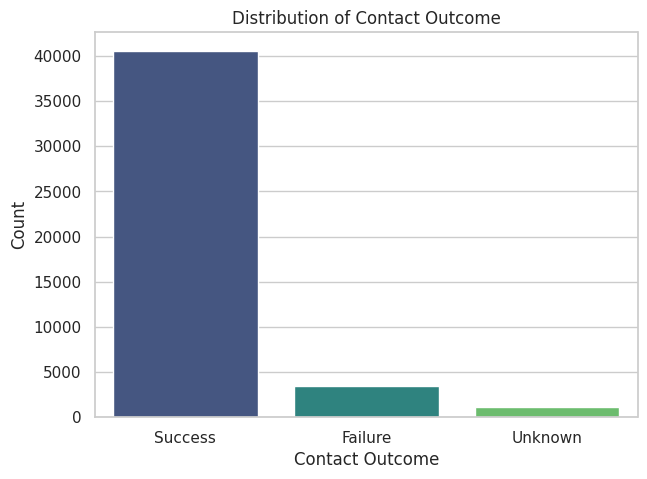

In [ ]:
# Distribution of Multinomial Target Variable
plt.figure(figsize=(7, 5))
sns.countplot(x='contact_outcome', data=df_bank, order=df_bank['contact_outcome'].value_counts().index, palette='viridis')
plt.title('Distribution of Contact Outcome')
plt.xlabel('Contact Outcome')
plt.ylabel('Count')
plt.show()

This plot shows the frequency of each `contact_outcome` category. As observed from the summary statistics, 'Success' is the most frequent outcome, followed by 'Failure' and then 'Unknown'.

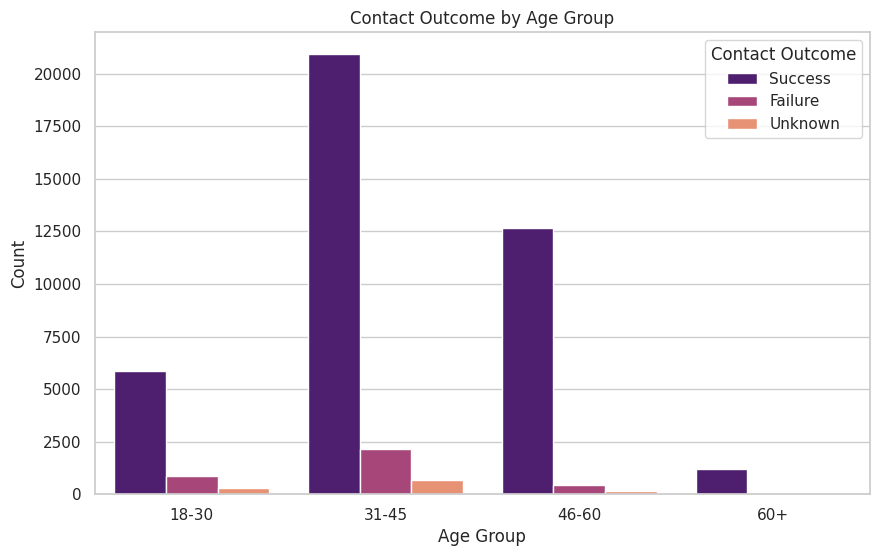

In [ ]:
# Relationship between Contact Outcome and Age (binned)
df_bank['age_group'] = pd.cut(df_bank['age'], bins=[18, 30, 45, 60, 95], labels=['18-30', '31-45', '46-60', '60+'])

plt.figure(figsize=(10, 6))
sns.countplot(x='age_group', hue='contact_outcome', data=df_bank, palette='magma')
plt.title('Contact Outcome by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Contact Outcome')
plt.show()

This plot illustrates how the `contact_outcome` varies across different `age_group`s. We can observe patterns regarding which age groups are more likely to result in 'Success', 'Failure', or 'Unknown' outcomes. For instance, certain age groups might show a higher proportion of 'Success' calls, aligning with the positive coefficient for age in the multinomial model (for some outcomes relative to the reference).

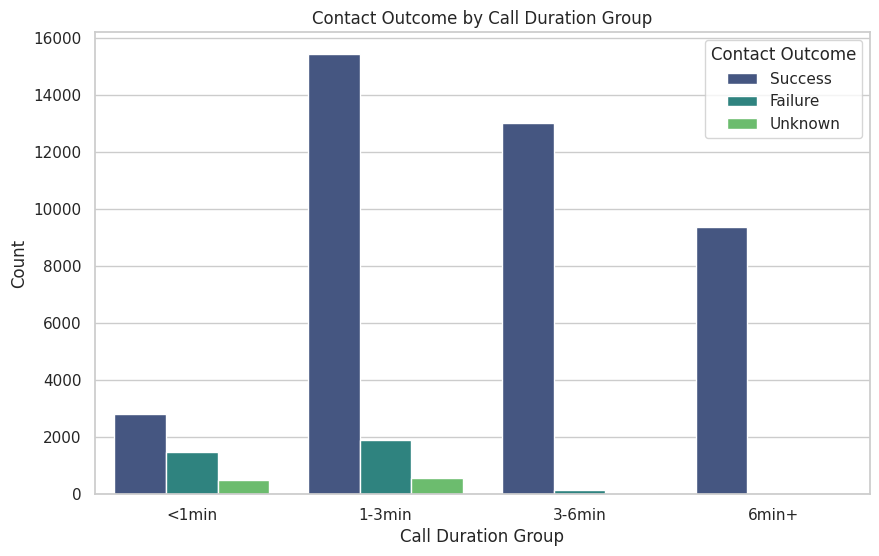

In [ ]:
# Relationship between Contact Outcome and Duration (binned)
df_bank['duration_group'] = pd.cut(df_bank['duration'], bins=[-1, 60, 180, 360, np.inf], labels=['<1min', '1-3min', '3-6min', '6min+'])

plt.figure(figsize=(10, 6))
sns.countplot(x='duration_group', hue='contact_outcome', data=df_bank, palette='viridis')
plt.title('Contact Outcome by Call Duration Group')
plt.xlabel('Call Duration Group')
plt.ylabel('Count')
plt.legend(title='Contact Outcome')
plt.show()

Here, we explore the relationship between call duration and the `contact_outcome`. It's expected that longer call durations might correlate with more successful outcomes, as `duration` was a highly significant predictor. This plot can visually confirm that trend, showing a higher proportion of 'Success' in longer call duration groups.

### Ordinal Logistic Regression Visualizations

/tmp/ipykernel_604/2235162886.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='interest_level', data=df_bank, order=['Low', 'Medium', 'High'], palette='cividis')


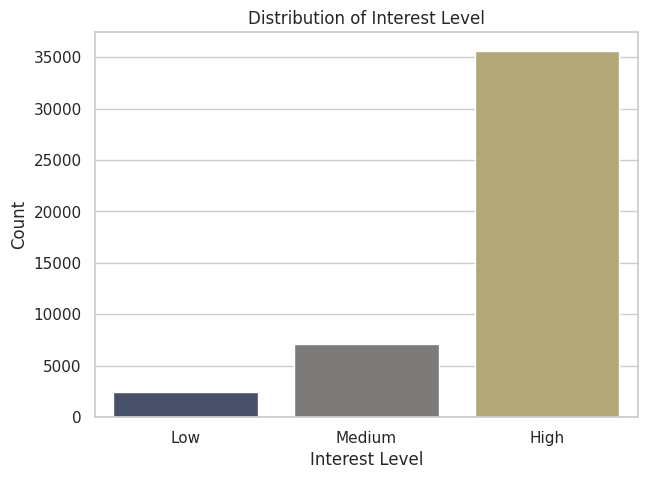

In [ ]:
# Distribution of Ordinal Target Variable
plt.figure(figsize=(7, 5))
sns.countplot(x='interest_level', data=df_bank, order=['Low', 'Medium', 'High'], palette='cividis')
plt.title('Distribution of Interest Level')
plt.xlabel('Interest Level')
plt.ylabel('Count')
plt.show()

This plot shows the distribution of the synthetic `interest_level` target variable. We can see the frequency of 'Low', 'Medium', and 'High' interest levels, confirming the overall class imbalance or balance in the created target.

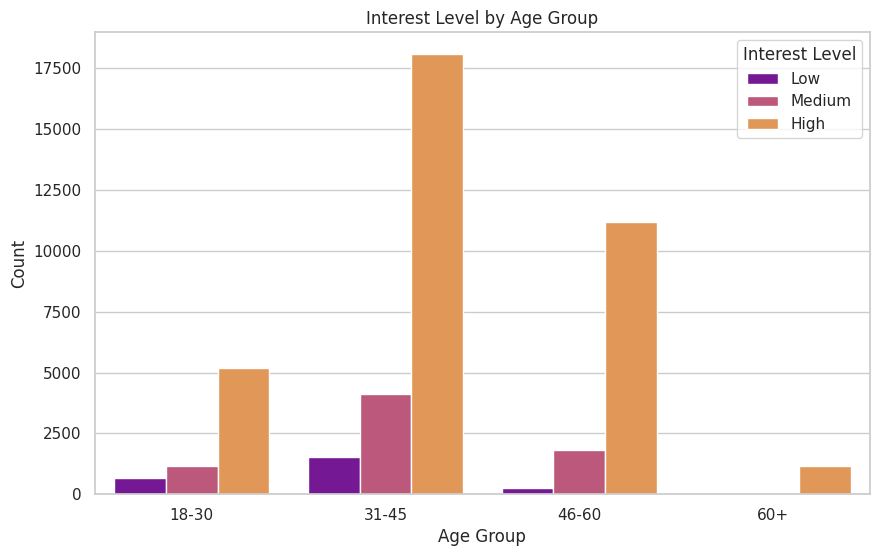

In [ ]:
# Relationship between Interest Level and Age Group
plt.figure(figsize=(10, 6))
sns.countplot(x='age_group', hue='interest_level', data=df_bank, palette='plasma', hue_order=['Low', 'Medium', 'High'])
plt.title('Interest Level by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Interest Level')
plt.show()

This visualization helps understand if certain age groups tend to have higher or lower interest levels. Given how `interest_level` was generated with a positive coefficient for `age`, we might expect to see a trend where older age groups have a higher proportion of 'High' interest.

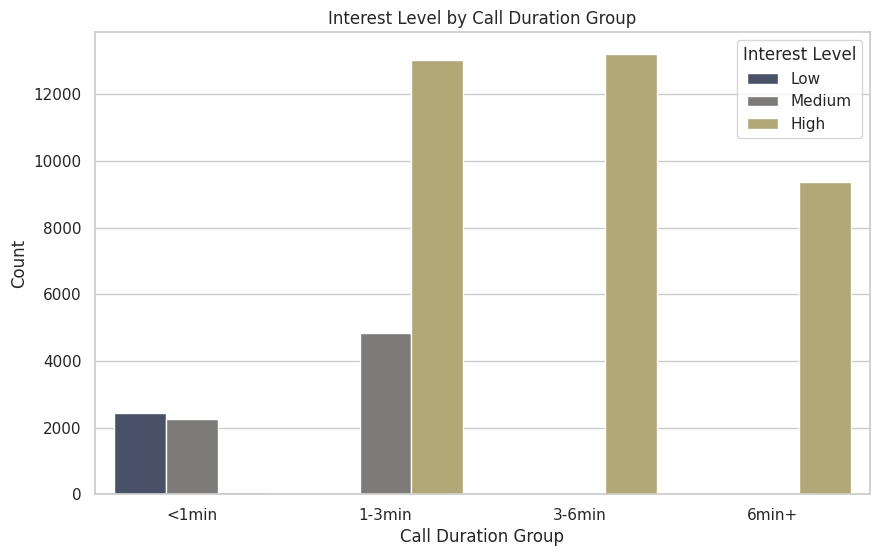

In [ ]:
# Relationship between Interest Level and Duration Group
plt.figure(figsize=(10, 6))
sns.countplot(x='duration_group', hue='interest_level', data=df_bank, palette='cividis', hue_order=['Low', 'Medium', 'High'])
plt.title('Interest Level by Call Duration Group')
plt.xlabel('Call Duration Group')
plt.ylabel('Count')
plt.legend(title='Interest Level')
plt.show()

Similar to `age`, `duration` was also a factor in generating the `interest_level`. This plot will show how `interest_level` changes with call duration. We can anticipate that longer calls are associated with higher interest levels, providing visual support for the underlying synthetic relationship.